# Assignment 2: Supervised Learning Techniques for E-Commerce Orders

This notebook is your working template for **Assignment 2**.

**Total Marks: 30**

**Learning Objectives:**
- Apply essential data preprocessing techniques to a dataset for supervised learning
- Prepare the data for classification modeling
- Apply supervised learning techniques to build and evaluate classification models

**Your Objective:**
Build supervised classification models to predict the **payment method (`payment_type`)** used for each order, based on order characteristics and order attributes.

Work **top-to-bottom**. Complete each task in order before moving on.

## Setup

Run the cell below to import the required Python packages.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

## Define Global Random State

Set your group's random state value. This must be used consistently throughout the assignment.

In [5]:
# TODO: Set RANDOM_STATE to your group number (1, 2, ..., 12)
RANDOM_STATE = 9  # Change this to your group number

print(f"Random state set to: {RANDOM_STATE}")

Random state set to: 9


---
# Part 1: Data Preparation [10 Marks]

In this section, you will prepare the transformed dataset for supervised classification. Proper data preparation is a critical step in the machine learning pipeline, as model performance and validity depend heavily on the quality, structure, and representation of the input data.

## 1.1 Data Loading and Splitting [2 Marks]

Load the dataset using Pandas and prepare train/test datasets.

**Instructions:**
1. Load the processed dataset from Assignment 1 using `pd.read_csv()`
2. Define features and target:
   - Set `payment_type` as the target variable
   - Set all remaining columns as input features
3. Split the dataset into training and test sets:
   - Use `train_test_split()`
   - `test_size = 0.2`
   - `random_state = RANDOM_STATE`
   - Name output variables as: `X_train`, `X_test`, `y_train`, `y_test`
4. Briefly explain the importance of using a test dataset.

In [6]:
# Load the processed dataset from Assignment 1
# TODO: Adjust the filename/path if needed

df = pd.read_csv('ecommerce_orders_cleaned.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (46287, 17)


,order_id,order_status,order_purchase_hour,order_purchase_dayofweek,order_purchase_month,order_total_value,num_items,num_unique_products,num_unique_sellers,total_item_price,avg_item_price,total_freight_value,top_product_category,customer_state,payment_type,order_value_per_item,order_size_category
0,sdv-id-whzjUX,shipped,10,4,4,744.312535,1,1,1,352.420029,369.966521,68.790159,construction_tools_construction,Massachusetts,voucher,352.420029,Small
1,sdv-id-dbopoJ,delivered,19,2,3,1556.667902,1,1,1,289.242639,1354.621410,15.394619,health_beauty,Vermont,credit_card,289.242639,Small
2,sdv-id-FSEOvM,delivered,15,4,8,62.060506,1,1,1,26.893468,48.485654,18.751282,luggage_accessories,South Carolina,debit_card,26.893468,Small
3,sdv-id-bQcBUR,delivered,21,0,8,73.873470,1,1,1,37.790896,75.704909,8.670875,computers_accessories,Kentucky,credit_card,37.790896,Small
4,sdv-id-MPxIXB,delivered,13,5,5,361.961537,3,3,3,169.528323,50.132979,34.731146,pet_shop,Missouri,voucher,56.509441,Medium


In [7]:
# TODO: Define features and target, then split the data

# Define target variable
y = df['payment_type']

# Define features (all columns except payment_type)
X = df.drop('payment_type', axis=1)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Print shapes to verify
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (37029, 16)
X_test shape: (9258, 16)
y_train shape: (37029,)
y_test shape: (9258,)


**TODO: Briefly explain the importance of using a test dataset.**

*To evaluate the preformance of model on unseen dataset, and help to avoid overfit.*

## 1.2 Handling Categorical Variables [4 Marks]

Prepare categorical variables for machine learning.

**Instructions:**
1. Identify all categorical columns
2. Apply label encoding:
   - Use `LabelEncoder` from scikit-learn
3. Ensure consistency across train and test sets:
   - Fit encoders on training data only
   - Transform both train and test sets
   - Handle any unseen categories appropriately
4. Briefly explain why categorical encoding is required for machine learning models

In [8]:
# TODO: Identify categorical columns

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['order_id', 'order_status', 'top_product_category', 'customer_state', 'order_size_category']


In [24]:
# TODO: Apply Label Encoding to categorical columns

# Create copies to avoid modifying original data
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Dictionary to store label encoders for each column
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    # Fit on training data
    le.fit(X_train_encoded[col].astype(str))

    # Transform train and test
    X_train_encoded[col] = le.transform(X_train_encoded[col].astype(str))

    # Handle unseen categories in test set
    known_classes = le.classes_.tolist()
    known_classes.append('<unknown>')
    le.classes_ = np.array(known_classes)

    test_col = X_test_encoded[col].astype(str)
    test_col = test_col.map(lambda x: x if x in known_classes else '<unknown>')

    X_test_encoded[col] = le.transform(test_col)

    # Store encoder
    label_encoders[col] = le

# Print the shape after encoding
print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape: {X_test_encoded.shape}")

X_train_encoded shape: (37029, 16)
X_test_encoded shape: (9258, 16)


**TODO: Briefly explain why categorical encoding is required for machine learning models.**

*Categorical encoding convert categorical variables into numerical representations, so that machine learning algorithms can process and handle them effectively.*

## 1.3 Handling Numerical Variables [4 Marks]

Scale numerical variables for modeling.

**Instructions:**
1. Identify all numerical columns
2. Use `StandardScaler` from scikit-learn for feature scaling
3. **Fit the scaler on X_train only**
4. Transform both X_train and X_test
5. Briefly explain why feature scaling is important for some classification models

In [10]:
# TODO: Identify numerical columns

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

Numerical columns: ['order_purchase_hour', 'order_purchase_dayofweek', 'order_purchase_month', 'order_total_value', 'num_items', 'num_unique_products', 'num_unique_sellers', 'total_item_price', 'avg_item_price', 'total_freight_value', 'order_value_per_item']


In [11]:
# TODO: Apply StandardScaler to numerical columns

scaler = StandardScaler()

# Fit on training data only, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train_encoded[numerical_cols])
X_test_scaled = scaler.transform(X_test_encoded[numerical_cols])

# Print the shape after scaling
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (37029, 11)
X_test_scaled shape: (9258, 11)


**TODO: Briefly explain why feature scaling is important for some classification models.**

*Feature scaling can prevent features with large values or range from dominating the model's prediction, and also improve the traing time and performance of the model.*

---
# Part 2: Applying Machine Learning Models [20 Marks]

In this section, you will train, evaluate, and compare multiple supervised classification models for predicting the payment method (`payment_type`). The objective is not only to build individual models, but also to perform a systematic comparison of their predictive performance and practical suitability for deployment.

## 2.1 Model Training

### 2.1.1 Logistic Regression [3 Marks]

Logistic Regression is a linear classification model that models the log-odds of the target class as a linear combination of the input features.

**Instructions:**
- Use `LogisticRegression()`
- Train on `X_train`, `y_train`
- Generate predictions on `X_test`
- Store the results in `y_pred_lr`

In [12]:
# TODO: Train Logistic Regression model

lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression training complete.")

Logistic Regression training complete.


### 2.1.2 Decision Trees [3 Marks]

Decision Trees is a tree-structured model that makes predictions by recursively splitting the feature space based on feature values.

**Instructions:**
- Use `DecisionTreeClassifier()`
- Train on `X_train`, `y_train`
- Generate predictions on `X_test`
- Store the results in `y_pred_dt`

In [13]:
# TODO: Train Decision Tree model

dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree training complete.")

Decision Tree training complete.


### 2.1.3 Kernel & Ensemble Methods [3 Marks]

There are other types of models beyond linear and single-tree approaches, each with distinct characteristics.

**Choose one of the following models to apply:** SVM, XGBoost, or Random Forest.

**Instructions:**
- Fit and predict the results with your selected model
- Store the predictions appropriately

In [26]:
# TODO: Train your chosen model (SVM, XGBoost, or Random Forest)
# SVM
svm_model = SVC(random_state=RANDOM_STATE)
svm_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM training complete.")

SVM training complete.


In [27]:
# TODO: Train your chosen model (SVM, XGBoost, or Random Forest)
# XGBoost
from xgboost import XGBClassifier
le_y = LabelEncoder()
y_train_encoded = le_y.fit_transform(y_train)
y_test_encoded = le_y.transform(y_test)

xgb_model = XGBClassifier(random_state=RANDOM_STATE)
xgb_model.fit(X_train_scaled, y_train_encoded)

# Generate predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost training complete.")

XGBoost training complete.


In [25]:
# TODO: Train your chosen model (SVM, XGBoost, or Random Forest)
# Random Forest
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest training complete.")

Random Forest training complete.


## 2.2 Evaluation & Visualization [4 Marks]

Evaluate and visualize performance for all three models.

**Instructions:**
1. Compute the following metrics:
   - Accuracy
   - Precision
   - Recall
   - F1-score
2. Compute the confusion matrix for each case:
   - Visualize the confusion matrix by plotting a heatmap using Seaborn
3. Present results in a clear, comparable format:
   - Table of metrics for all three models
   - Side-by-side or clearly labelled confusion matrix plots
4. Briefly comment on:
   - Strengths and weaknesses of each model
   - Any impact of class imbalance handling

In [28]:
# TODO: Compute evaluation metrics for all three models

def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Evaluate all models
results = [
    evaluate_model(y_test, y_pred_lr, 'Logistic Regression'),
    evaluate_model(y_test, y_pred_dt, 'Decision Tree'),
    evaluate_model(y_test, y_pred_rf, 'Random Forest')  # or your chosen model
]

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.615360,0.568235,0.615360,0.491462
1,Decision Tree,0.505725,0.512395,0.505725,0.508834
2,Random Forest,0.620868,0.609298,0.620868,0.568990


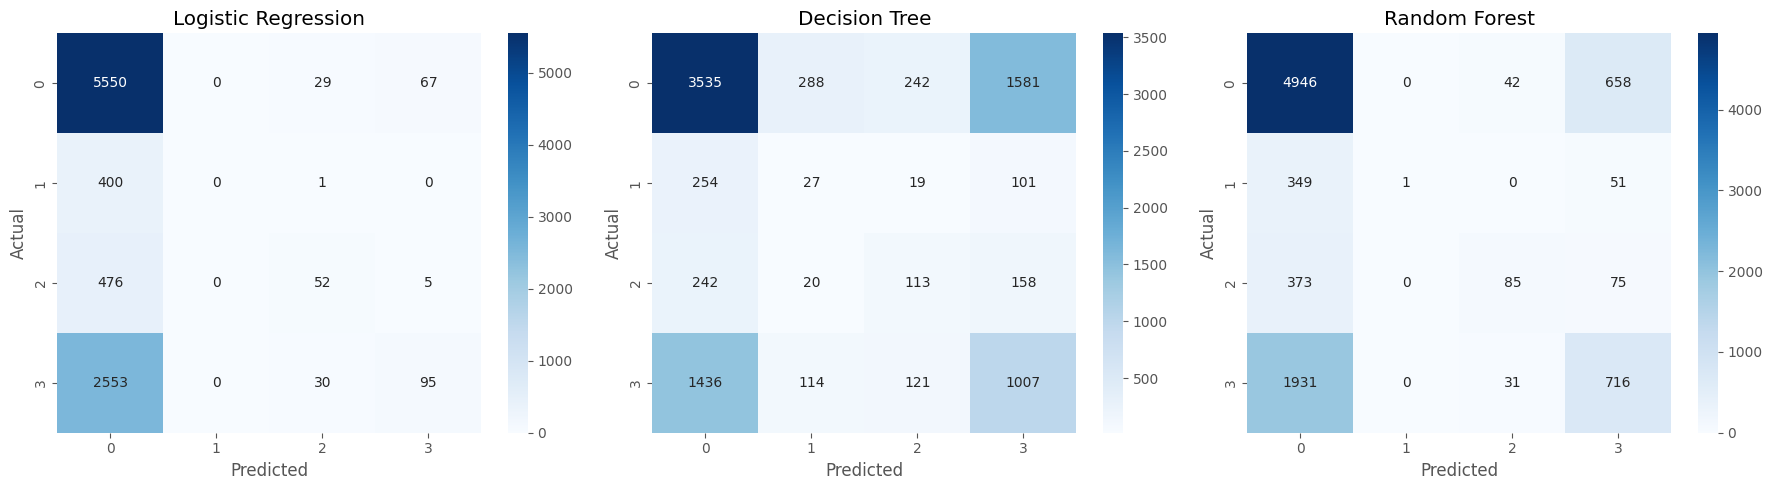

In [29]:
# TODO: Plot confusion matrices for all three models

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_confusion_matrix(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plot_confusion_matrix(y_test, y_pred_lr, axes[0], 'Logistic Regression')
plot_confusion_matrix(y_test, y_pred_dt, axes[1], 'Decision Tree')
plot_confusion_matrix(y_test, y_pred_rf, axes[2], 'Random Forest')  # or your chosen model

plt.tight_layout()
plt.show()

**TODO: Briefly comment on the strengths and weaknesses of each model, and any impact of class imbalance handling.**

*Logistic Regression: Achieves a relatively high overall Accuracy (0.615) and is computationally fast. However, as a linear model, it failed to capture the minority classes.*

*Decision Tree: Better at capturing non-linear relationships. The confusion matrix shows it actually attempts to predict minority classes However, it makes many misclassifications across all classes, resulting in the lowest overall Accuracy (0.505).*

*Random Forest: The best overall performer, achieving the highest Accuracy (0.621) and F1-Score (0.569). However, the computations took longer time and it still struggles with the minority classes.*

* **Impact of Class Imbalance Handling**
No explicit class imbalance handling was applied, and all models exhibit a strong bias toward the majority class to minimize overall error.

## 2.3 Model Selection & Final Recommendation [7 Marks]

Compare the performance of the models and select the most suitable one based on evaluation results.

**Instructions:**
1. Select the best performing model for predicting `payment_type`
2. Justify your choice based on:
   - Evaluation metrics
   - Class imbalance considerations
   - Model complexity and interpretability
   - Practical deployment considerations
3. Briefly explain why this model is preferred over the others
4. Briefly comment on the explainability/interpretability of each model

In [30]:
# TODO: Display final comparison and analysis

# Display the results table
print("Model Performance Comparison:")
print(results_df.to_string(index=False))

# Identify the best model based on your criteria
best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f"\nBest performing model: {best_model}")

Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.615360   0.568235 0.615360  0.491462
      Decision Tree  0.505725   0.512395 0.505725  0.508834
      Random Forest  0.620868   0.609298 0.620868  0.568990

Best performing model: Random Forest


### Final Recommendation

**TODO: Select and justify your choice of the best model.**

**Selected Model:** *[Your choice here]*

**Justification based on:**

1. **Evaluation Metrics:**
   - *Your analysis here...*

2. **Class Imbalance Considerations:**
   - *Your analysis here...*

3. **Model Complexity and Interpretability:**
   - *Your analysis here...*

4. **Practical Deployment Considerations:**
   - *Your analysis here...*

**Why this model is preferred over others:**
*Your explanation here...*

### Model Explainability/Interpretability

**TODO: Comment on the explainability/interpretability of each model.**

**Logistic Regression:**
- *Your comments here...*

**Decision Tree:**
- *Your comments here...*

**[Your Third Model]:**
- *Your comments here...*

---
## Conclusion

*Summarize your findings and key takeaways from this assignment.*